# Inspección inicial del conjunto de datos MMOTU - OTU_2D

## Objetivo

Realizar una inspección del conjunto de datos OTU_2D de MMOTU con la finalidad de verificar su estructura, disponibilidad de imágenes, anotaciones, etiquetas y particiones antes de la ejecución de las etapas de preparación y organización.

Esta inspección se realiza únicamente en modo lectura sobre los datos originales.

> **Prerrequisitos.** Para reproducir esta etapa desde cero es necesario disponer localmente del dataset fuente MMOTU / OTU_2D en `data/raw/MMOTU/OTU_2D/` (`images/`, `annotations/`, `train.txt`, `val.txt`, `train_cls.txt` y `val_cls.txt`). El dataset no se distribuye con el repositorio.
>

In [54]:
# Importar librerías necesarias
from pathlib import Path
from collections import Counter

import sys
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# Verificacuión de versiones de las librerías
print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("OpenCV:", cv2.__version__)

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
NumPy: 2.5.2
Pandas: 3.0.5
OpenCV: 5.0.0


In [55]:
# Ruta raíz del proyecto
def locate_project_root() -> Path:
    current_dir = Path.cwd().resolve()

    for candidate in [current_dir, *current_dir.parents]:
        if (
            (candidate / "src").exists()
            and (candidate / "data").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto."
    )


PROJECT_ROOT = locate_project_root()

# Dataset original
DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "MMOTU" / "OTU_2D"

# Directorios principales
IMAGES_DIR = DATASET_DIR / "images"
ANNOTATIONS_DIR = DATASET_DIR / "annotations"

# Archivos de partición y clasificación
TRAIN_FILE = DATASET_DIR / "train.txt"
VAL_FILE = DATASET_DIR / "val.txt"
TRAIN_CLS_FILE = DATASET_DIR / "train_cls.txt"
VAL_CLS_FILE = DATASET_DIR / "val_cls.txt"

print("Raiz del proyecto: ", PROJECT_ROOT)
print("Dataset: ", DATASET_DIR)
print()
print("Dataset existe: ", DATASET_DIR.exists())
print("Directorio de imágenes existe: ", IMAGES_DIR.exists())
print("Directorio de anotaciones existe: ", ANNOTATIONS_DIR.exists())
print("Archivo de entrenamiento existe: ", TRAIN_FILE.exists())
print("Archivo de validación existe: ", VAL_FILE.exists())
print("Archivo de entrenamiento de clasificación existe: ", TRAIN_CLS_FILE.exists())
print("Archivo de validación de clasificación existe: ", VAL_CLS_FILE.exists())

Raiz del proyecto:  c:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\proyecto_ia_tumores_ovaricos
Dataset:  c:\Users\PC\Desktop\JARITZA - PUCP\26-2\Tesis\proyecto_ia_tumores_ovaricos\data\raw\MMOTU\OTU_2D

Dataset existe:  True
Directorio de imágenes existe:  True
Directorio de anotaciones existe:  True
Archivo de entrenamiento existe:  True
Archivo de validación existe:  True
Archivo de entrenamiento de clasificación existe:  True
Archivo de validación de clasificación existe:  True


## 1. Verificación de la estructura física del conjunto de datos

Se identifica la cantidad de imágenes y los archivos de anotación disponibles en el conjunto original. Además, se verifica la correspondencia entre cada imagen ecográfica y las tres variantes de anotación encontradas en el directorio `annotations`.

In [56]:
# Archivos de imágenes
image_files = sorted([
    path for path in IMAGES_DIR.iterdir()
    if path.is_file() and path.suffix.lower() in {".jpg", ".png"}
])

# Archivos de anotaciones
annotation_files = sorted([
    path for path in ANNOTATIONS_DIR.iterdir()
    if path.is_file() and path.suffix.lower() == ".png"
])

print("Número de imágenes: ", len(image_files))
print("Número de anotaciones: ", len(annotation_files))

Número de imágenes:  1469
Número de anotaciones:  4407


In [57]:
# Clasificación de los archivos de anotación según su sufijo
annotation_types = {
    "base": [],
    "binary": [],
    "binary_binary": [],
}

for path in annotation_files:
    stem = path.stem

    if stem.endswith("_binary_binary"):
        annotation_types["binary_binary"].append(path)
    elif stem.endswith("_binary"):
        annotation_types["binary"].append(path)
    else:
        annotation_types["base"].append(path)

print("Anotaciones base: ", len(annotation_types["base"]))
print("Anotaciones _binary: ", len(annotation_types["binary"]))
print("Anotaciones _binary_binary: ", len(annotation_types["binary_binary"]))

Anotaciones base:  1469
Anotaciones _binary:  1469
Anotaciones _binary_binary:  1469


In [58]:
# Identificadores de las imágenes
image_ids = {path.stem for path in image_files}

# Identificadores de cada variante de anotación
base_ids = {
    path.stem 
    for path in annotation_types["base"]
}

binary_ids = {
    path.stem.removesuffix("_binary")
    for path in annotation_types["binary"]
}

binary_binary_ids = {
    path.stem.removesuffix("_binary_binary")
    for path in annotation_types["binary_binary"]
}

# Archivos faltantes respecto a las imágenes
missing_base = image_ids - base_ids
missing_binary = image_ids - binary_ids
missing_binary_binary = image_ids - binary_binary_ids

# Anotaciones sin imagen correspondiente
extra_base = base_ids - image_ids
extra_binary = binary_ids - image_ids
extra_binary_binary = binary_binary_ids - image_ids

print("Anotaciones base faltantes: ", len(missing_base))
print("Anotaciones _binary faltantes: ", len(missing_binary))
print("Anotaciones _binary_binary faltantes: ", len(missing_binary_binary))
print()
print("Anotaciones base sin imagen: ", len(extra_base))
print("Anotaciones _binary sin imagen: ", len(extra_binary))
print("Anotaciones _binary_binary sin imagen: ", len(extra_binary_binary))

Anotaciones base faltantes:  0
Anotaciones _binary faltantes:  0
Anotaciones _binary_binary faltantes:  0

Anotaciones base sin imagen:  0
Anotaciones _binary sin imagen:  0
Anotaciones _binary_binary sin imagen:  0


## 2. Verificación de las particiones y etiquetas de clasificación

Se verifican los archivos de entrenamiento y validación proporcionados por MMOTU. La verificación incluye la cantidad de registros, la correspondencia entre los archivos de partición y clasificación y la totalidad de imágenes disponibles.

In [59]:
def read_split_file(file_path):
    """
    Lee un  archivo de partición como train.txt o val.txt y retorna una lista con los identificadores de las imágenes.
    """
    with open(file_path, "r", encoding="utf-8") as file:
        ids = [
            line.strip()
            for line in file
            if line.strip()
        ]
    return ids

def read_classification_file(file_path):
    """
    Lee un archivo como train_cls.txt o val_cls.txt.
    Retorna un Dataframe con: image_name, image_id, original_class.
    """
    records = []
    with open(file_path, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            image_name = parts[0]
            original_class = int(parts[1])

            records.append({
                "image_name": image_name,
                "image_id": Path(image_name).stem,
                "original_class": original_class
            })
    return pd.DataFrame(records)


In [60]:
train_ids = read_split_file(TRAIN_FILE)
val_ids = read_split_file(VAL_FILE)

train_cls = read_classification_file(TRAIN_CLS_FILE)
val_cls = read_classification_file(VAL_CLS_FILE)

print("Registros train.txt:", len(train_ids))
print("Registros val.txt:", len(val_ids))
print("Registros train_cls.txt:", len(train_cls))
print("Registros val_cls.txt:", len(val_cls))

Registros train.txt: 1000
Registros val.txt: 469
Registros train_cls.txt: 1000
Registros val_cls.txt: 469


In [61]:
train_ids_set = set(train_ids)
val_ids_set = set(val_ids)

train_cls_ids = set(train_cls["image_id"])
val_cls_ids = set(val_cls["image_id"])

# Diferencias entre archivos
train_missing_in_cls = train_ids_set - train_cls_ids
train_extra_in_cls = train_cls_ids - train_ids_set
val_missing_in_cls = val_ids_set - val_cls_ids
val_extra_in_cls = val_cls_ids - val_ids_set

print("Train sin etiqueta:", len(train_missing_in_cls))
print("Etiquetas train sin ID:", len(train_extra_in_cls))
print()
print("Validation sin etiqueta:", len(val_missing_in_cls))
print("Etiquetas validation sin ID:", len(val_extra_in_cls))

Train sin etiqueta: 0
Etiquetas train sin ID: 0

Validation sin etiqueta: 0
Etiquetas validation sin ID: 0


In [62]:
train_duplicates = len(train_ids) - len(set(train_ids))
val_duplicates = len(val_ids) - len(set(val_ids))

train_cls_duplicates = train_cls["image_id"].duplicated().sum()
val_cls_duplicates = val_cls["image_id"].duplicated().sum()

print("IDs duplicados en train.txt:", train_duplicates)
print("IDs duplicados en val.txt:", val_duplicates)
print("IDs duplicados en train_cls.txt:", train_cls_duplicates)
print("IDs duplicados en val_cls.txt:", val_cls_duplicates)

IDs duplicados en train.txt: 0
IDs duplicados en val.txt: 0
IDs duplicados en train_cls.txt: 0
IDs duplicados en val_cls.txt: 0


In [63]:
# Verificación de data leakage entre train y validation
train_val_overlap = train_ids_set.intersection(val_ids_set)

print("Imágenes presentes simultáneamente en train y validation:", len(train_val_overlap))

Imágenes presentes simultáneamente en train y validation: 0


In [64]:
# Verificación de consistencia entre particiones y dataset
split_ids = train_ids_set.union(val_ids_set)

missing_from_splits = image_ids - split_ids
extra_in_splits = split_ids - image_ids

print("Total de IDs unicos en train y validation:", len(split_ids))
print("Imágenes no incluidas en las particiones:", len(missing_from_splits))
print("IDs de particiones sin imagen física:", len(extra_in_splits))

Total de IDs unicos en train y validation: 1469
Imágenes no incluidas en las particiones: 0
IDs de particiones sin imagen física: 0


In [65]:
# Verificación de las etiquetas de clasificación originales
all_cls = pd.concat(
    [
        train_cls.assign(split="train"),
        val_cls.assign(split="validation")
    ],
    ignore_index=True
)

original_classes = sorted(all_cls["original_class"].unique())

print("Clases originales encontradas:", original_classes)
print("Número de clases originales:", len(original_classes))

Clases originales encontradas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Número de clases originales: 8


## 3. Inspección de etiquetas y criterio binario

El subconjunto OTU_2D de MMOTU proporciona etiquetas de clasificación correspondientes a ocho categorías originales, codificadas mediante valores del 0 al 7. Las etiquetas originales de MMOTU se conservan y los archivos originales del conjunto de datos no son modificados.

Debido a que la investigación plantea una clasificación binaria de las imágenes ecográficas, se adopta una agrupación en dos clases: **benigno (0)** y **maligno (1)**, siguiendo el criterio empleado en el estudio de referencia basado en YOLOv8 aplicado sobre el mismo conjunto de datos.

In [68]:
# Nombres de las categorías originales de MMOTU
CLASS_NAMES = {
    0: "Chocolate cyst",
    1: "Serous cystadenoma",
    2: "Teratoma",
    3: "Theca cell tumor",
    4: "Simple cyst",
    5: "Normal ovary",
    6: "Mucinous cystadenoma",
    7: "High-grade serous"
}

# Incorporar únicamente el nombre descriptivo.
# La etiqueta original 0-7 se conserva.
all_cls["original_class_name"] = all_cls["original_class"].map(CLASS_NAMES)

# Verificar que todas las etiquetas encontradas estén contempladas
unknown_classes = all_cls[
    all_cls["original_class_name"].isna()
]

print("Número de registros:", len(all_cls))
print("Etiquetas originales sin identificar:", len(unknown_classes))
print("Clases encontradas:", sorted(all_cls["original_class"].unique()))

Número de registros: 1469
Etiquetas originales sin identificar: 0
Clases encontradas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


In [69]:
# Calcular la distribución original de clases en train y validation

original_distribution = pd.crosstab(
    all_cls["original_class"],
    all_cls["split"]
)

# Mantener un orden consistente
original_distribution = original_distribution.reindex(
    index=range(8),
    columns=["train", "validation"],
    fill_value=0
)

# Agregar nombres descriptivos
original_distribution.insert(
    0,
    "category",
    [CLASS_NAMES[class_id] for class_id in original_distribution.index]
)

# Total por categoría
original_distribution["total"] = (
    original_distribution["train"]
    + original_distribution["validation"]
)

original_distribution

split,category,train,validation,total
original_class,,,,
0,Chocolate cyst,226,110,336
1,Serous cystadenoma,153,66,219
2,Teratoma,228,108,336
3,Theca cell tumor,57,31,88
4,Simple cyst,47,19,66
5,Normal ovary,180,87,267
6,Mucinous cystadenoma,71,33,104
7,High-grade serous,38,15,53


In [70]:
# Criterio de agrupación binaria
# 0 = benigno
# 1 = maligno

BINARY_LABEL_MAP = {
    0: 0,
    1: 0,
    2: 0,
    3: 0,
    4: 0,
    5: 0,
    6: 1,
    7: 1
}

BINARY_CLASS_NAMES = {
    0: "benign",
    1: "malignant"
}

# Aplicación temporal sobre el DataFrame utilizado para la inspección
all_cls["binary_label"] = (
    all_cls["original_class"]
    .map(BINARY_LABEL_MAP)
)

all_cls["binary_class"] = (
    all_cls["binary_label"]
    .map(BINARY_CLASS_NAMES)
)

# Verificar que todas las imágenes recibieron una etiqueta binaria
print(
    "Etiquetas binarias sin asignar:",
    all_cls["binary_label"].isna().sum()
)

all_cls.head()

Etiquetas binarias sin asignar: 0


,image_name,image_id,original_class,split,binary_label,original_class_name,binary_class
0,658.JPG,658,5,train,0,Normal ovary,benign
1,384.JPG,384,3,train,0,Theca cell tumor,benign
2,367.JPG,367,3,train,0,Theca cell tumor,benign
3,730.JPG,730,1,train,0,Serous cystadenoma,benign
4,1426.JPG,1426,7,train,1,High-grade serous,malignant


In [71]:
# Distribución de las clases binarias en train y validation

binary_distribution = pd.crosstab(
    all_cls["binary_class"],
    all_cls["split"]
)

binary_distribution = binary_distribution.reindex(
    index=["benign", "malignant"],
    columns=["train", "validation"],
    fill_value=0
)

binary_distribution["total"] = (
    binary_distribution["train"]
    + binary_distribution["validation"]
)

binary_distribution

split,train,validation,total
binary_class,,,
benign,891,421,1312
malignant,109,48,157


In [72]:
EXPECTED_BINARY_DISTRIBUTION = {
    ("benign", "train"): 891,
    ("benign", "validation"): 421,
    ("malignant", "train"): 109,
    ("malignant", "validation"): 48
}

for (class_name, split), expected_value in EXPECTED_BINARY_DISTRIBUTION.items():

    obtained_value = binary_distribution.loc[
        class_name,
        split
    ]

    assert obtained_value == expected_value, (
        f"Distribución inesperada para {class_name} - {split}. "
        f"Esperado: {expected_value}, obtenido: {obtained_value}"
    )

print("Distribución binaria verificada correctamente.")

Distribución binaria verificada correctamente.


## 4. Inspección técnica de imágenes y máscaras

Se examinan las propiedades técnicas de las imágenes ecográficas y de las máscaras binarias de segmentación asociadas. Para la inspección de las anotaciones de segmentación se consideran los archivos con sufijo `_binary.PNG`.

### 4.1 Obtención de propiedades técnicas

Se recorren las imágenes y sus máscaras correspondientes para obtener sus principales características técnicas y detectar posibles archivos que no puedan ser leídos correctamente.

In [73]:
def get_channel_count(array):
    """Retorna el número de canales de una imagen."""
    if array is None:
        return None

    if array.ndim == 2:
        return 1

    if array.ndim == 3:
        return array.shape[2]

    return None


def get_unique_pixel_info(array, preview_limit=10):
    """
    Obtiene el número de valores de píxel distintos.

    Para imágenes de un canal analiza valores individuales.
    Para imágenes multicanal analiza combinaciones de canales por píxel.
    """
    if array is None:
        return None, None

    if array.ndim == 2:
        unique_values = np.unique(array)
        preview = tuple(unique_values[:preview_limit].tolist())

    elif array.ndim == 3:
        pixels = array.reshape(-1, array.shape[2])
        unique_values = np.unique(pixels, axis=0)

        preview = tuple(
            tuple(pixel.tolist())
            for pixel in unique_values[:preview_limit]
        )

    else:
        return None, None

    return len(unique_values), preview

In [74]:
# Inspección de las parejas

technical_records = []

for index, image_path in enumerate(image_files, start=1):

    image_id = image_path.stem

    # Máscara binaria correspondiente
    mask_path = ANNOTATIONS_DIR / f"{image_id}_binary.PNG"

    # Lectura sin modificar canales ni profundidad
    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_UNCHANGED
    )

    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_UNCHANGED
    )

    image_readable = image is not None
    mask_readable = mask is not None

    # Valores por defecto
    image_height = None
    image_width = None
    image_channels = None
    image_dtype = None
    image_min = None
    image_max = None

    mask_height = None
    mask_width = None
    mask_channels = None
    mask_dtype = None
    mask_unique_count = None
    mask_unique_preview = None

    same_dimensions = False

    if image_readable:
        image_height, image_width = image.shape[:2]
        image_channels = get_channel_count(image)
        image_dtype = str(image.dtype)
        image_min = image.min().item()
        image_max = image.max().item()

    if mask_readable:
        mask_height, mask_width = mask.shape[:2]
        mask_channels = get_channel_count(mask)
        mask_dtype = str(mask.dtype)

        (
            mask_unique_count,
            mask_unique_preview
        ) = get_unique_pixel_info(mask)

    if image_readable and mask_readable:
        same_dimensions = (
            image_height == mask_height
            and image_width == mask_width
        )

    technical_records.append({
        "image_id": image_id,

        "image_format": image_path.suffix.upper(),
        "image_width": image_width,
        "image_height": image_height,
        "image_channels": image_channels,
        "image_dtype": image_dtype,
        "image_min": image_min,
        "image_max": image_max,
        "image_readable": image_readable,

        "mask_format": mask_path.suffix.upper(),
        "mask_width": mask_width,
        "mask_height": mask_height,
        "mask_channels": mask_channels,
        "mask_dtype": mask_dtype,
        "mask_unique_count": mask_unique_count,
        "mask_unique_preview": mask_unique_preview,
        "mask_readable": mask_readable,

        "same_dimensions": same_dimensions
    })

    # Indicador simple de progreso
    if index % 250 == 0:
        print(f"Procesadas {index}/{len(image_files)} muestras")

technical_df = pd.DataFrame(technical_records)

print(f"Inspección finalizada: {len(technical_df)} muestras")

technical_df.head()

Procesadas 250/1469 muestras
Procesadas 500/1469 muestras
Procesadas 750/1469 muestras
Procesadas 1000/1469 muestras
Procesadas 1250/1469 muestras
Inspección finalizada: 1469 muestras


,image_id,image_format,image_width,image_height,image_channels,image_dtype,image_min,image_max,image_readable,mask_format,mask_width,mask_height,mask_channels,mask_dtype,mask_unique_count,mask_unique_preview,mask_readable,same_dimensions
0,1,.JPG,959,537,3,uint8,0,255,True,.PNG,959,537,1,uint8,2,"(0, 1)",True,True
1,10,.JPG,483,542,3,uint8,0,255,True,.PNG,483,542,1,uint8,2,"(0, 1)",True,True
2,100,.JPG,958,531,3,uint8,0,255,True,.PNG,958,531,1,uint8,2,"(0, 1)",True,True
3,1000,.JPG,959,532,3,uint8,0,255,True,.PNG,959,532,1,uint8,2,"(0, 1)",True,True
4,1001,.JPG,480,530,3,uint8,0,255,True,.PNG,480,530,1,uint8,2,"(0, 1)",True,True


### 4.2 Formatos, canales y tipos de dato

Se verifica que los archivos puedan ser leídos correctamente y se identifican los formatos, número de canales y tipos de dato presentes en las imágenes y máscaras.

In [78]:
# Verificación de legibilidad, formato, canales y tipos de datos
print(
    "Imágenes no legibles:",
    (~technical_df["image_readable"]).sum()
)
print(
    "Máscaras no legibles:",
    (~technical_df["mask_readable"]).sum()
)
print("-" * 40)

print("Formatos de imágenes:")
print(technical_df["image_format"].value_counts())
print("\nFormatos de máscaras:")
print(technical_df["mask_format"].value_counts())
print("-" * 40)

print("Número de canales en imágenes:")
print(technical_df["image_channels"].value_counts().sort_index())
print("\nNúmero de canales en máscaras:")
print(technical_df["mask_channels"].value_counts().sort_index())
print("-" * 40)

print("Tipos de dato de las imágenes:")
print(technical_df["image_dtype"].value_counts())
print("\nTipos de dato de las máscaras:")
print(technical_df["mask_dtype"].value_counts())

Imágenes no legibles: 0
Máscaras no legibles: 0
----------------------------------------
Formatos de imágenes:
image_format
.JPG    1469
Name: count, dtype: int64

Formatos de máscaras:
mask_format
.PNG    1469
Name: count, dtype: int64
----------------------------------------
Número de canales en imágenes:
image_channels
3    1469
Name: count, dtype: int64

Número de canales en máscaras:
mask_channels
1    1469
Name: count, dtype: int64
----------------------------------------
Tipos de dato de las imágenes:
image_dtype
uint8    1469
Name: count, dtype: int64

Tipos de dato de las máscaras:
mask_dtype
uint8    1469
Name: count, dtype: int64


### 4.3 Distribución de dimensiones

Se analiza la variabilidad de las dimensiones espaciales presentes en las imágenes originales y en sus máscaras asociadas. El objetivo es caracterizar esta variabilidad como una propiedad del conjunto de datos. La adecuación del tamaño de entrada se definirá posteriormente, de acuerdo con los requerimientos de las arquitecturas utilizadas.

In [79]:
# Inspección de dimensiones diferentes existentes entre imágenes y máscaras
image_dimensions = (
    technical_df
    .groupby(["image_width", "image_height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

mask_dimensions = (
    technical_df
    .groupby(["mask_width", "mask_height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(
    "Número de dimensiones diferentes en imágenes:",
    len(image_dimensions)
)

print(
    "Número de dimensiones diferentes en máscaras:",
    len(mask_dimensions)
)

Número de dimensiones diferentes en imágenes: 859
Número de dimensiones diferentes en máscaras: 859


In [80]:
# Tamaños mas frecuentes en imágenes y máscaras
image_dimensions.head(20)
mask_dimensions.head(20)

,mask_width,mask_height,count
588,958,534,26
587,958,533,20
589,958,535,20
631,959,535,19
586,958,532,17
629,959,533,14
630,959,534,14
632,959,536,14
628,959,532,14
585,958,531,13


In [81]:
# Resumen estadístico de las dimensiones de imágenes y máscaras

dimension_summary = technical_df[
    [
        "image_width",
        "image_height",
        "mask_width",
        "mask_height"
    ]
].agg(["min", "max", "nunique"])

dimension_summary

,image_width,image_height,mask_width,mask_height
min,302,266,302,266
max,1135,794,1135,794
nunique,185,186,185,186


### 4.4 Correspondencia dimensional entre imágenes y máscaras

Se verifica que cada máscara binaria presente las mismas dimensiones espaciales que la imagen ecográfica correspondiente.

In [82]:
# Correspondencia dimensional entre imágenes y máscaras
dimension_mismatches = technical_df[
    ~technical_df["same_dimensions"]
]

print(
    "Pares imagen-máscara con dimensiones diferentes:",
    len(dimension_mismatches)
)

Pares imagen-máscara con dimensiones diferentes: 0


### 4.5 Valores presentes en las máscaras binarias

Se inspecciona el número de valores distintos presentes en cada máscara `_binary.PNG`. Esta comprobación permite determinar si las anotaciones utilizadas para segmentación presentan una codificación binaria consistente.

In [83]:
# Valores presentes en las máscaras binarias
mask_value_distribution = (
    technical_df["mask_unique_count"]
    .value_counts()
    .sort_index()
)

mask_value_distribution

mask_unique_count
2    1469
Name: count, dtype: int64

In [86]:
# Posibilidad que las máscaras tengan más de dos valores distintos (0 y 255)
non_binary_masks = technical_df[
    technical_df["mask_unique_count"] > 2
]
print(
    "Máscaras con más de dos valores distintos:",
    len(non_binary_masks)
)

# Posibilidad que exista alguna máscara con un solo valor
single_value_masks = technical_df[
    technical_df["mask_unique_count"] == 1
]
print(
    "Máscaras con un único valor:",
    len(single_value_masks)
)

Máscaras con más de dos valores distintos: 0
Máscaras con un único valor: 0


In [87]:
# Valores encontrados en las máscaras
(
    technical_df[
        ["mask_unique_count", "mask_unique_preview"]
    ]
    .drop_duplicates()
    .sort_values("mask_unique_count")
)

,mask_unique_count,mask_unique_preview
0,2,"(0, 1)"


### 4.6 Relación de aspecto de las imágenes

Se analiza la relación entre el ancho y el alto de las imágenes originales con el fin de determinar el grado de variabilidad geométrica del conjunto.

In [88]:
# Relación de aspecto de las imágenes
technical_df["aspect_ratio"] = (
    technical_df["image_width"]
    / technical_df["image_height"]
)

technical_df["aspect_ratio"].describe()

count    1469.000000
mean        1.390523
std         0.430415
min         0.721386
25%         0.905838
50%         1.555735
75%         1.795886
max         2.104283
Name: aspect_ratio, dtype: float64

In [89]:
orientation_counts = pd.Series({
    "horizontal": (technical_df["image_width"] > technical_df["image_height"]).sum(),
    "vertical": (technical_df["image_width"] < technical_df["image_height"]).sum(),
    "square": (technical_df["image_width"] == technical_df["image_height"]).sum()
})

orientation_counts

horizontal    865
vertical      603
square          1
dtype: int64

In [90]:
print(
    "Relación de aspecto mínima:",
    technical_df["aspect_ratio"].min()
)
print(
    "Relación de aspecto máxima:",
    technical_df["aspect_ratio"].max()
)
print(
    "Relación de aspecto mediana:",
    technical_df["aspect_ratio"].median()
)

Relación de aspecto mínima: 0.7213855421686747
Relación de aspecto máxima: 2.1042830540037243
Relación de aspecto mediana: 1.555735056542811


### 4.7 Verificación de los canales de las imágenes

Aunque las ecografías se encuentran almacenadas con tres canales, se verifica si los valores de dichos canales son equivalentes o presentan información diferente.

In [92]:
identical_channels = 0
different_channels = 0

for image_path in image_files:

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR
    )

    b, g, r = cv2.split(image)

    if (
        np.array_equal(b, g)
        and np.array_equal(g, r)
    ):
        identical_channels += 1
    else:
        different_channels += 1

print(
    "Imágenes con canales idénticos:",
    identical_channels
)

print(
    "Imágenes con diferencias entre canales:",
    different_channels
)

Imágenes con canales idénticos: 1
Imágenes con diferencias entre canales: 1468


In [94]:
# Medida de diferencia entre canales de las imágenes
channel_analysis = []

for image_path in image_files:

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR
    )

    b, g, r = cv2.split(image)

    # Píxeles donde los tres canales son exactamente iguales
    grayscale_pixels = (
        (b == g) &
        (g == r)
    )

    grayscale_percentage = (
        grayscale_pixels.sum()
        / grayscale_pixels.size
        * 100
    )

    # Diferencia máxima entre canales por píxel
    image_int = image.astype(np.int16)

    channel_range = (
        image_int.max(axis=2)
        - image_int.min(axis=2)
    )

    channel_analysis.append({
        "image_id": image_path.stem,
        "equal_channels_percentage": grayscale_percentage,
        "mean_channel_difference": channel_range.mean(),
        "max_channel_difference": channel_range.max()
    })

channel_df = pd.DataFrame(channel_analysis)

channel_df.describe()

,equal_channels_percentage,mean_channel_difference,max_channel_difference
count,1469.000000,1469.000000,1469.000000
mean,59.018213,2.789061,174.377127
std,36.146014,2.393228,42.001517
min,5.192798,0.000000,0.000000
25%,23.108336,0.419819,151.000000
50%,49.948229,2.756861,174.000000
75%,96.412933,4.416306,196.000000
max,100.000000,16.427258,255.000000


In [95]:
print(
    "Mediana de píxeles con canales idénticos:",
    channel_df["equal_channels_percentage"].median()
)
print(
    "Mínimo porcentaje de píxeles con canales idénticos:",
    channel_df["equal_channels_percentage"].min()
)
print(
    "Mediana de diferencia entre canales:",
    channel_df["mean_channel_difference"].median()
)

Mediana de píxeles con canales idénticos: 49.94822862240347
Mínimo porcentaje de píxeles con canales idénticos: 5.192797960484385
Mediana de diferencia entre canales: 2.75686055087871


In [96]:
channel_df.sort_values(
    "equal_channels_percentage"
).head(10)

,image_id,equal_channels_percentage,mean_channel_difference,max_channel_difference
30,1025,5.192798,4.645797,176
32,1027,5.388819,4.842571,205
1444,977,5.490288,5.768791,167
77,1068,5.689356,4.328082,144
1449,981,5.853374,5.125801,183
1463,994,5.856639,5.299746,166
75,1066,6.106061,4.060169,168
737,34,6.222629,4.595849,166
78,1069,6.263324,4.604736,207
704,31,6.461221,5.188111,176


### 4.8 Magnitud de las diferencias entre canales - Sección Extra

Debido a que la mayoría de las imágenes presenta diferencias entre sus tres canales, se cuantifica la proporción de píxeles cuya diferencia entre canales supera distintos umbrales.

In [97]:
channel_threshold_records = []

for image_path in image_files:

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR
    ).astype(np.int16)

    # Diferencia entre el canal de mayor y menor intensidad
    channel_range = (
        image.max(axis=2)
        - image.min(axis=2)
    )

    total_pixels = channel_range.size

    channel_threshold_records.append({
        "image_id": image_path.stem,
        "pct_diff_gt_5": (
            (channel_range > 5).sum()
            / total_pixels * 100
        ),
        "pct_diff_gt_10": (
            (channel_range > 10).sum()
            / total_pixels * 100
        ),
        "pct_diff_gt_30": (
            (channel_range > 30).sum()
            / total_pixels * 100
        ),
        "pct_diff_gt_100": (
            (channel_range > 100).sum()
            / total_pixels * 100
        )
    })

channel_threshold_df = pd.DataFrame(
    channel_threshold_records
)

channel_threshold_df.describe()

,pct_diff_gt_5,pct_diff_gt_10,pct_diff_gt_30,pct_diff_gt_100
count,1469.000000,1469.000000,1469.000000,1469.000000
mean,16.148932,4.080093,0.661882,0.187113
std,16.687704,6.879531,0.946471,0.448177
min,0.000000,0.000000,0.000000,0.000000
25%,1.505602,0.683855,0.221591,0.015969
50%,10.163201,1.181722,0.317156,0.040853
75%,27.101607,4.152530,0.767396,0.131906
max,88.887644,74.630863,14.155345,5.257968


In [98]:
# Identificación de imágenes representativas
representative_ids = (
    channel_df
    .sort_values("equal_channels_percentage")
    .head(5)["image_id"]
    .tolist()
)

representative_ids

['1025', '1027', '977', '1068', '981']

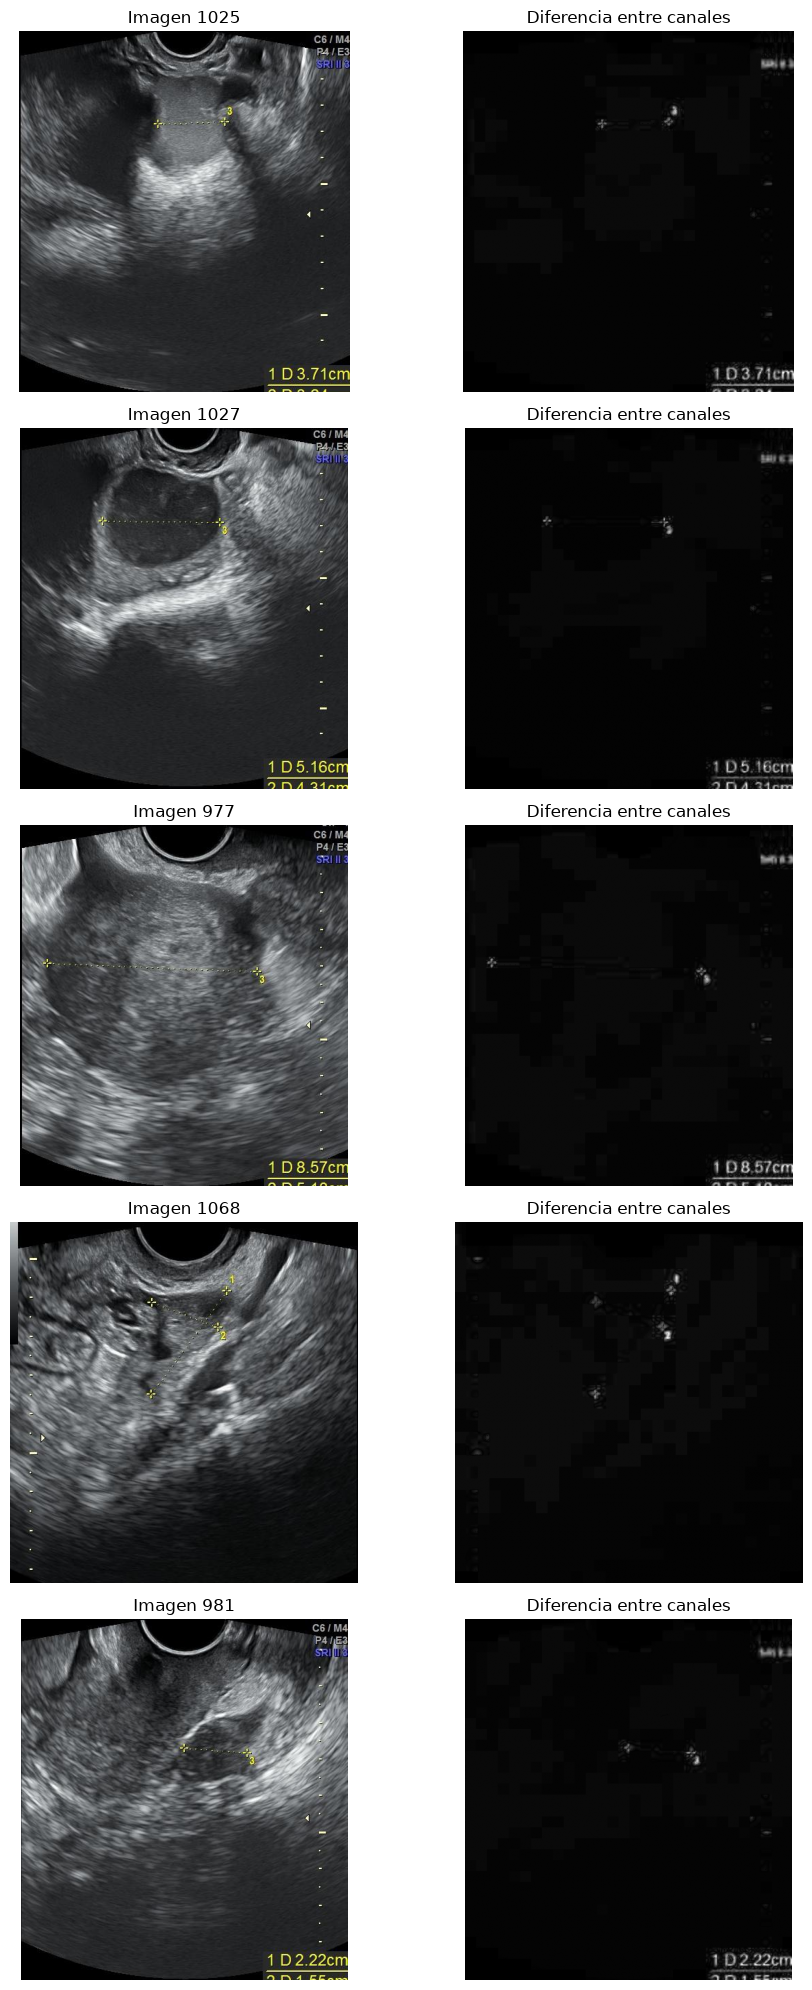

In [99]:
fig, axes = plt.subplots(
    len(representative_ids),
    2,
    figsize=(10, 4 * len(representative_ids))
)

for row, image_id in enumerate(representative_ids):

    image_path = IMAGES_DIR / f"{image_id}.JPG"

    image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    image_int = image_bgr.astype(np.int16)

    channel_range = (
        image_int.max(axis=2)
        - image_int.min(axis=2)
    )

    axes[row, 0].imshow(image_rgb)
    axes[row, 0].set_title(
        f"Imagen {image_id}"
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        channel_range,
        cmap="gray"
    )
    axes[row, 1].set_title(
        "Diferencia entre canales"
    )
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

## 5. Resumen de hallazgos

Esta inspección permitió verificar la estructura, integridad y principales características técnicas del subconjunto OTU_2D de MMOTU antes de implementar las operaciones de preparación del conjunto de datos.

- Se verificó la disponibilidad de las imágenes ecográficas, las anotaciones y los archivos originales de partición y clasificación. Asimismo, se comprobó la correspondencia entre las imágenes y sus anotaciones, así como la cobertura de las muestras en las particiones originales de entrenamiento y validación de MMOTU.

- Las etiquetas originales de MMOTU fueron conservadas y se verificó el criterio de agrupación binaria que será aplicado posteriormente durante la preparación del conjunto.

- Las imágenes presentan un formato homogéneo y pueden ser leídas correctamente. Las máscaras `_binary.PNG` poseen codificación binaria consistente y mantienen correspondencia espacial con sus respectivas imágenes. Asimismo, se identificó una elevada variabilidad en las dimensiones y relaciones de aspecto de las ecografías. Este hallazgo se documenta como una característica del conjunto: en R2 las imágenes y máscaras se conservan en sus dimensiones originales, y la adecuación de tamaño se definirá posteriormente de acuerdo con las arquitecturas utilizadas.

- Finalmente, las imágenes se conservarán en su representación original de tres canales. Aunque se identificaron diferencias entre canales, las diferencias cromáticas de mayor magnitud se concentran en una proporción reducida de píxeles, principalmente en elementos gráficos superpuestos. En esta etapa no se aplicará conversión a escala de grises ni eliminación de dichos elementos.

Los hallazgos obtenidos en esta inspección serán utilizados como requisitos técnicos para la implementación del código fuente del pipeline.

In [ ]:
# Tabla resumen
inspection_summary = pd.DataFrame([
    {
        "aspect": "Imágenes ecográficas",
        "result": len(image_files),
        "implication": "Conjunto disponible para procesamiento"
    },
    {
        "aspect": "Máscaras binarias",
        "result": len(annotation_types["binary"]),
        "implication": "Una máscara binaria por imagen"
    },
    {
        "aspect": "Imágenes no legibles",
        "result": int((~technical_df["image_readable"]).sum()),
        "implication": "No se detectaron archivos corruptos"
    },
    {
        "aspect": "Máscaras no legibles",
        "result": int((~technical_df["mask_readable"]).sum()),
        "implication": "No se detectaron máscaras corruptas"
    },
    {
        "aspect": "Formato de imágenes",
        "result": ", ".join(technical_df["image_format"].unique()),
        "implication": "No se requiere conversión de formato"
    },
    {
        "aspect": "Formato de máscaras",
        "result": ", ".join(technical_df["mask_format"].unique()),
        "implication": "Formato homogéneo"
    },
    {
        "aspect": "Canales de imágenes",
        "result": ", ".join(
            map(str, sorted(technical_df["image_channels"].unique()))
        ),
        "implication": "Se conservarán los 3 canales originales"
    },
    {
        "aspect": "Canales de máscaras",
        "result": ", ".join(
            map(str, sorted(technical_df["mask_channels"].unique()))
        ),
        "implication": "Representación adecuada para segmentación"
    },
    {
        "aspect": "Valores de máscaras",
        "result": "{0, 1}",
        "implication": "No se requiere binarización adicional"
    },
    {
        "aspect": "Resoluciones diferentes",
        "result": len(image_dimensions),
        "implication": "Se requiere estandarización dimensional"
    },
    {
        "aspect": "Rango de aspect ratio",
        "result": (
            f"{technical_df['aspect_ratio'].min():.3f} - "
            f"{technical_df['aspect_ratio'].max():.3f}"
        ),
        "implication": "Debe evitarse deformación geométrica innecesaria"
    },
    {
        "aspect": "Desajustes imagen-máscara",
        "result": len(dimension_mismatches),
        "implication": "Correspondencia espacial completa"
    },
    {
        "aspect": "Solapamiento train-validation",
        "result": len(train_val_overlap),
        "implication": "No se detectó fuga directa de muestras"
    }
])

inspection_summary

,aspect,result,implication
0,Imágenes ecográficas,1469,Conjunto disponible para procesamiento
1,Máscaras binarias,1469,Una máscara binaria por imagen
2,Imágenes no legibles,0,No se detectaron archivos corruptos
3,Máscaras no legibles,0,No se detectaron máscaras corruptas
4,Formato de imágenes,.JPG,No se requiere conversión de formato
5,Formato de máscaras,.PNG,Formato homogéneo
6,Canales de imágenes,3,Se conservarán los 3 canales originales
7,Canales de máscaras,1,Representación adecuada para segmentación
8,Valores de máscaras,"{0, 1}",No se requiere binarización adicional
9,Resoluciones diferentes,859,Se requiere estandarización dimensional


### 5.1 Requisitos derivados para la implementación del pipeline

- Los datos originales deberán ser utilizados únicamente como fuente de lectura.
- Se deberá mantener la correspondencia entre cada imagen, su máscara binaria, su etiqueta original y su partición.
- Se utilizarán las máscaras con sufijo `_binary.PNG` como máscaras de segmentación de referencia.
- Las etiquetas originales de MMOTU deberán conservarse junto con la etiqueta binaria generada para mantener la trazabilidad.
- No será necesaria una conversión de formatos de imágenes.
- Las máscaras deberán conservar su codificación binaria original.
- Las imágenes se conservarán inicialmente en tres canales.
- Las imágenes y máscaras se conservarán en sus dimensiones originales; la constitución del conjunto de datos no incluye una estandarización dimensional.
- Cualquier adecuación geométrica que se defina posteriormente para las arquitecturas deberá aplicarse de manera equivalente a cada imagen y su máscara correspondiente.
- Una eventual estrategia de redimensionamiento deberá considerar la variabilidad de las relaciones de aspecto para evitar deformaciones innecesarias.
- Los archivos que no cumplan las condiciones de integridad deberán registrarse sin modificar el conjunto original.